# 30 — Depression & Diabetes Management: Glycemic Outcomes

**Purpose**: NB29 established that 1 in 3 Insulin patients screens positive for depression
(CES-D-10 ≥ 10). This notebook asks the follow-up question: **within each age group and
diabetes category, do depressed patients manage their diabetes differently from
non-depressed patients?**

Four glycemic metrics are compared between depressed and non-depressed patients:
1. **Mean glucose** (mg/dL) — from the CGM wearable sensor manifest
2. **HbA1c** (%) — from laboratory measurement.csv
3. **Time above range** (TAR, % time > 180 mg/dL) — proxy for time spent in spike
4. **Spikes per day** (discrete hyperglycemic episodes > 180 mg/dL, ≥ 10 min)

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.
All results stay in memory only — no files are written to disk.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year_of_birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — CES-D-10 items
- Azure `{STUDY_ID}/dataset/clinical_data/measurement.csv` — HbA1c lab values
- Azure `{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv` — CGM summary (mean glucose)
- Azure individual CGM JSON files (streamed per participant) — TAR + spike counts

> **⚠️ Runtime note**: Cells 1–6 run in < 5 minutes. Cell 7 (CGM spike streaming)
> takes ~15–25 minutes. Results are kept in memory — no files are written.

---

**Table of Contents**
1. Environment Setup
2. Azure Connection + Core Data (participants, age)
3. CES-D-10 → Depression Flag
4. HbA1c from measurement.csv
5. CGM Manifest → Mean Glucose
6. CGM Streaming → TAR & Spikes (in memory only)
7. Merge All Sources
8. Analysis 1 — Overall: Depressed vs Non-Depressed on 4 Metrics
9. Analysis 2 — By Diabetes Group
10. Analysis 3 — By Age Band
11. Analysis 4 — Full Stratification: Age Band × Diabetes Group
12. Analysis 5 — Regression: Does Depression Independently Predict Glycemic Outcomes?
13. Key Findings

---

In [1]:
# ── 1. Environment Setup ────────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels', 'tqdm']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, json, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}
GROUP_COLORS  = {'Healthy': '#66C2A5', 'Pre-DM': '#4DAFFA', 'Oral Med': '#F5A623', 'Insulin': '#E8413E'}
DEP_COLORS    = {'Depressed': '#C0392B', 'Non-Depressed': '#2980B9'}

AGE_BAND_EDGES  = [0, 50, 60, 70, 120]
AGE_BAND_LABELS = ['<50', '50–59', '60–69', '70+']

DEPRESSION_CUTOFF  = 10
SPIKE_THRESHOLD    = 180
MIN_SPIKE_READINGS = 2    # ≥2 consecutive readings = ≥10 min

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection + Core Data ───────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
else:
    _cwd = Path.cwd()
    repo_root = str(_cwd.parent if (_cwd.parent / 'config' / 'azure_config.py').exists() else _cwd)
    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)
    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)
    print(f'.env found={_env_path.exists()}  |  repo_root={repo_root}')
    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING empty — check .env')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Loading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']
print(f'  {len(person):,} rows  age range: {person["age"].min():.0f}–{person["age"].max():.0f}')

.env found=True  |  repo_root=/Users/evanlee/Desktop/ucsf-tech-aireadi
Loading participants.tsv ...
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...
  2,280 rows  age range: 41–94


In [3]:
# ── 3. CES-D-10 → Depression Flag ─────────────────────────────────
print('Loading observation.csv (~108 MB) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'  {len(obs_raw):,} rows')

obs_raw['item_key']    = (obs_raw['observation_source_value']
                          .astype(str).str.split(',', n=1).str[0].str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan

CESD_KEYS = [f'ces{i}' for i in range(1, 11)] + ['cestl']
cesd_obs  = obs_raw[obs_raw['item_key'].isin(CESD_KEYS)].copy()

cesd_wide = (cesd_obs[['person_id', 'item_key', 'value_clean']]
             .pivot_table(index='person_id', columns='item_key',
                          values='value_clean', aggfunc='first'))

if 'cestl' in cesd_wide.columns:
    cesd_wide = cesd_wide.rename(columns={'cestl': 'cesd_total'})
else:
    item_cols = [c for c in cesd_wide.columns if c.startswith('ces')]
    for col in ['ces5', 'ces8']:
        if col in cesd_wide.columns:
            cesd_wide[col] = 3 - cesd_wide[col]
    cesd_wide['cesd_total'] = cesd_wide[item_cols].sum(axis=1, skipna=False)

cesd_out = cesd_wide[['cesd_total']].reset_index()
cesd_out['depressed'] = (cesd_out['cesd_total'] >= DEPRESSION_CUTOFF).astype(float)
cesd_out['dep_label'] = cesd_out['depressed'].map({1.0: 'Depressed', 0.0: 'Non-Depressed'})

print(f'CES-D-10 data: {cesd_out["cesd_total"].notna().sum():,} participants')
print(f'Depression rate: {cesd_out["depressed"].mean()*100:.1f}%  '
      f'({cesd_out["depressed"].sum():.0f} depressed)')

Loading observation.csv (~108 MB) ...
  707,126 rows
CES-D-10 data: 2,277 participants
Depression rate: 20.0%  (455 depressed)


In [4]:
# ── 4. HbA1c from measurement.csv ──────────────────────────────────
print('Loading measurement.csv (large file ~100+ MB) ...')
try:
    meas = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/measurement.csv')
    print(f'  {len(meas):,} rows × {meas.shape[1]} cols')

    # HbA1c filter: concept ID or source value pattern
    hba1c_concept_ids = {4184637, 3004410, 3005673, 40758583}
    mask_concept = (meas['measurement_concept_id'].isin(hba1c_concept_ids)
                    if 'measurement_concept_id' in meas.columns
                    else pd.Series(False, index=meas.index))
    mask_source  = (meas['measurement_source_value'].astype(str).str.lower()
                    .str.contains('import_hba1c', na=False))
    hba1c_raw = meas[mask_concept | mask_source].copy()
    print(f'  HbA1c rows found: {len(hba1c_raw):,}')

    # Plausibility filter (3–20%), take most recent per person
    val_col = 'value_as_number'
    hba1c_clean = hba1c_raw.dropna(subset=[val_col]).copy()
    hba1c_clean = hba1c_clean[(hba1c_clean[val_col] >= 3) & (hba1c_clean[val_col] <= 20)]

    if 'measurement_date' in hba1c_clean.columns:
        hba1c_clean['measurement_date'] = pd.to_datetime(
            hba1c_clean['measurement_date'], errors='coerce')
        hba1c_clean = hba1c_clean.sort_values('measurement_date')

    hba1c_df = (hba1c_clean.groupby('person_id')[val_col]
                .last().reset_index().rename(columns={val_col: 'hba1c'}))
    print(f'  Participants with HbA1c: {len(hba1c_df):,}')
    print(f'  Range: {hba1c_df["hba1c"].min():.1f}–{hba1c_df["hba1c"].max():.1f}%  '
          f'mean {hba1c_df["hba1c"].mean():.2f}%')
    HBAIC_AVAILABLE = True

except Exception as e:
    print(f'  WARNING: measurement.csv load failed — {e}')
    print('  HbA1c analysis will be skipped.')
    hba1c_df = pd.DataFrame(columns=['person_id', 'hba1c'])
    HBAIC_AVAILABLE = False

Loading measurement.csv (large file ~100+ MB) ...
  242,279 rows × 26 cols
  HbA1c rows found: 2,219
  Participants with HbA1c: 2,211
  Range: 3.8–17.0%  mean 6.12%


In [5]:
# ── 5. CGM Manifest → Mean Glucose ────────────────────────────────
print('Loading CGM manifest ...')
try:
    cgm_manifest = load_blob_csv(
        f'{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv', sep='\t')
    cgm_manifest.columns = cgm_manifest.columns.str.strip().str.lower()
    print(f'  Manifest rows: {len(cgm_manifest):,}')
    print(f'  Columns: {cgm_manifest.columns.tolist()}')

    # Standardise column names
    rename_map = {
        'average_glucose_level_mg_dl':            'mean_glucose',
        'glucose_sensor_sampling_duration_days':   'cgm_days',
        'glucose_level_record_count':              'cgm_record_count',
    }
    cgm_manifest = cgm_manifest.rename(columns={k: v for k, v in rename_map.items()
                                                 if k in cgm_manifest.columns})

    # Derive readings_per_day if not present
    if 'readings_per_day' not in cgm_manifest.columns:
        if 'cgm_record_count' in cgm_manifest.columns and 'cgm_days' in cgm_manifest.columns:
            cgm_manifest['readings_per_day'] = (
                cgm_manifest['cgm_record_count'] /
                cgm_manifest['cgm_days'].replace(0, np.nan))

    # Store filepath column name for streaming cell
    fp_col = next((c for c in cgm_manifest.columns
                   if 'filepath' in c or 'file_path' in c or 'filename' in c), None)
    print(f'  Filepath column: {fp_col}')

    cgm_slim = cgm_manifest[['person_id'] +
                             [c for c in ['mean_glucose', 'cgm_days', 'readings_per_day']
                              if c in cgm_manifest.columns]].copy()
    print(f'  Participants with mean_glucose: '
          f'{cgm_slim["mean_glucose"].notna().sum() if "mean_glucose" in cgm_slim.columns else 0:,}')
    CGM_MANIFEST_AVAILABLE = 'mean_glucose' in cgm_slim.columns

except Exception as e:
    print(f'  WARNING: CGM manifest load failed — {e}')
    print('  Check if wearable_blood_glucose/manifest.tsv exists under current STUDY_ID.')
    cgm_manifest = pd.DataFrame()
    cgm_slim = pd.DataFrame(columns=['person_id'])
    fp_col = None
    CGM_MANIFEST_AVAILABLE = False

Loading CGM manifest ...
  Manifest rows: 2,245
  Columns: ['person_id', 'glucose_filepath', 'glucose_level_record_count', 'average_glucose_level_mg_dl', 'glucose_sensor_sampling_duration_days', 'glucose_sensor_id', 'manufacturer', 'manufacturer_model_name']
  Filepath column: glucose_filepath
  Participants with mean_glucose: 2,245


In [6]:
# ── 6. CGM Streaming → TAR & Spikes per Day ───────────────────────
# Reads individual CGM JSON files to compute:
#   tar_pct       : % readings > 180 mg/dL (time above range)
#   spikes_per_day: discrete hyperglycemic episodes per day (≥10 min, > 180 mg/dL)
#
# ⚠️  Takes ~15–25 minutes on first run. Results stay in memory only — no files written.

from tqdm.auto import tqdm

def parse_cgm_json(raw_bytes):
    """Extract glucose values from AI-READI CGM JSON. Returns array or None."""
    try:
        data = json.loads(raw_bytes.decode('utf-8'))
    except Exception:
        return None
    readings = None
    if isinstance(data, dict):
        body = data.get('body', {})
        if isinstance(body, dict) and 'cgm' in body:
            readings = body['cgm']
    if readings is None and isinstance(data, list):
        readings = data
    if not readings:
        return None
    vals = []
    for r in readings:
        if isinstance(r, dict):
            bg = r.get('blood_glucose', {})
            v  = bg.get('value') if isinstance(bg, dict) else r.get('value')
            if v is None:
                v = r.get('glucose_value') or r.get('displayValue')
        else:
            v = None
        try:
            fv = float(v)
            if 40 <= fv <= 400:
                vals.append(fv)
        except (TypeError, ValueError):
            pass
    return np.array(vals) if len(vals) >= 12 else None

def compute_tar_spikes(g, threshold=180, min_spike_readings=2):
    """Return tar_pct (% > threshold) and spikes_per_day (discrete episodes/day)."""
    tar    = float(np.mean(g > threshold) * 100)
    above  = g > threshold
    spikes = 0
    run    = 0
    for a in above:
        if a:
            run += 1
        else:
            if run >= min_spike_readings:
                spikes += 1
            run = 0
    if run >= min_spike_readings:
        spikes += 1
    days = max(len(g) * 5 / 1440, 0.01)  # readings every ~5 min
    return tar, round(spikes / days, 2)

if not CGM_MANIFEST_AVAILABLE or fp_col is None:
    print('CGM manifest or filepath column not available — skipping spike streaming.')
    print('TAR and spikes_per_day will not be included in analyses.')
    spike_df = pd.DataFrame(columns=['person_id', 'tar_pct', 'spikes_per_day'])
    CGM_SPIKE_AVAILABLE = False
else:
    path_map = {}
    for _, row in cgm_manifest.iterrows():
        pid = str(row['person_id'])
        fp  = row.get(fp_col)
        if pd.notna(fp):
            blob_path = (f"{STUDY_ID}/dataset{fp}"
                         if str(fp).startswith('/') else
                         f"{STUDY_ID}/dataset/{fp}")
            path_map[pid] = blob_path

    print(f'Streaming {len(path_map):,} CGM files (this takes ~15–25 min) ...')

    spike_records = []
    failed = 0
    for pid, blob_path in tqdm(path_map.items(), desc='CGM files'):
        try:
            bc  = container.get_blob_client(blob_path)
            raw = bc.download_blob().readall()
            g   = parse_cgm_json(raw)
            if g is not None:
                tar, spd = compute_tar_spikes(g, SPIKE_THRESHOLD, MIN_SPIKE_READINGS)
                spike_records.append({'person_id': pid, 'tar_pct': tar, 'spikes_per_day': spd})
        except Exception:
            failed += 1

    spike_df = pd.DataFrame(spike_records)
    print(f'Done. {len(spike_df):,} processed, {failed} failed.')
    CGM_SPIKE_AVAILABLE = len(spike_df) > 0

Streaming 2,245 CGM files (this takes ~15–25 min) ...


CGM files:   0%|          | 0/2245 [00:00<?, ?it/s]

Done. 2,243 processed, 0 failed.


In [7]:
# ── 7. Merge All Sources ───────────────────────────────────────────

df = (participants[['person_id', 'study_group_code', 'study_group_label']]
      .merge(person[['person_id', 'age']], on='person_id', how='left')
      .merge(cesd_out[['person_id', 'cesd_total', 'depressed', 'dep_label']],
             on='person_id', how='left'))

if HBAIC_AVAILABLE and len(hba1c_df) > 0:
    hba1c_df['person_id'] = hba1c_df['person_id'].astype(df['person_id'].dtype)
    df = df.merge(hba1c_df, on='person_id', how='left')
else:
    df['hba1c'] = np.nan

if CGM_MANIFEST_AVAILABLE and len(cgm_slim) > 0:
    cgm_slim['person_id'] = cgm_slim['person_id'].astype(df['person_id'].dtype)
    df = df.merge(cgm_slim, on='person_id', how='left')
else:
    df['mean_glucose'] = np.nan

if CGM_SPIKE_AVAILABLE and len(spike_df) > 0:
    spike_df['person_id'] = spike_df['person_id'].astype(df['person_id'].dtype)
    df = df.merge(spike_df[['person_id', 'tar_pct', 'spikes_per_day']],
                  on='person_id', how='left')
else:
    df['tar_pct']        = np.nan
    df['spikes_per_day'] = np.nan

df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
df['age_band'] = pd.cut(df['age'], bins=AGE_BAND_EDGES,
                         labels=AGE_BAND_LABELS, right=False)
df['age_band'] = pd.Categorical(df['age_band'], categories=AGE_BAND_LABELS, ordered=True)
df['age_std']  = (df['age'] - df['age'].mean()) / df['age'].std()

# Glycemic metrics list (only include those with data)
GLYCEMIC_METRICS = {
    'mean_glucose':   'Mean Glucose (mg/dL)',
    'hba1c':          'HbA1c (%)',
    'tar_pct':        'Time Above Range (% > 180 mg/dL)',
    'spikes_per_day': 'Spikes per Day (episodes > 180 mg/dL)',
}
AVAILABLE_METRICS = {k: v for k, v in GLYCEMIC_METRICS.items()
                     if df[k].notna().sum() > 50}

print(f'Final df: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'CES-D-10 data: {df["cesd_total"].notna().sum():,}')
print(f'Depressed (≥{DEPRESSION_CUTOFF}): {df["depressed"].sum():.0f}  '
      f'({df["depressed"].mean()*100:.1f}%)')
print('\nMetric coverage:')
for m, label in GLYCEMIC_METRICS.items():
    n = df[m].notna().sum()
    print(f'  {label:<45}: {n:,} ({n/len(df)*100:.1f}%)')
print(f'\nAvailable for analysis: {list(AVAILABLE_METRICS.keys())}')

Final df: 2,280 rows × 15 cols
CES-D-10 data: 2,277
Depressed (≥10): 455  (20.0%)

Metric coverage:
  Mean Glucose (mg/dL)                         : 2,245 (98.5%)
  HbA1c (%)                                    : 2,211 (97.0%)
  Time Above Range (% > 180 mg/dL)             : 2,243 (98.4%)
  Spikes per Day (episodes > 180 mg/dL)        : 2,243 (98.4%)

Available for analysis: ['mean_glucose', 'hba1c', 'tar_pct', 'spikes_per_day']


---
## 8. Analysis 1 — Overall: Depressed vs Non-Depressed on 4 Metrics

> **Question**: Across the full cohort (ignoring age and diabetes group), are glycemic
> outcomes significantly worse in patients who screen positive for depression?
>
> **Method**: Mann-Whitney U test for each metric. FDR correction across the 4 tests.

=== Overall: Depressed vs Non-Depressed — Glycemic Metrics ===
                                label  n_dep  mean_dep  mean_nodep  delta_median     p  p_fdr  significant
                 Mean Glucose (mg/dL)    441   141.710     133.730         3.320 0.005  0.010         True
                            HbA1c (%)    427     6.350       6.070         0.100 0.002  0.007         True
     Time Above Range (% > 180 mg/dL)    440    16.870      11.470         1.280 0.042  0.056        False
Spikes per Day (episodes > 180 mg/dL)    440     1.650       1.500         0.110 0.370  0.370        False


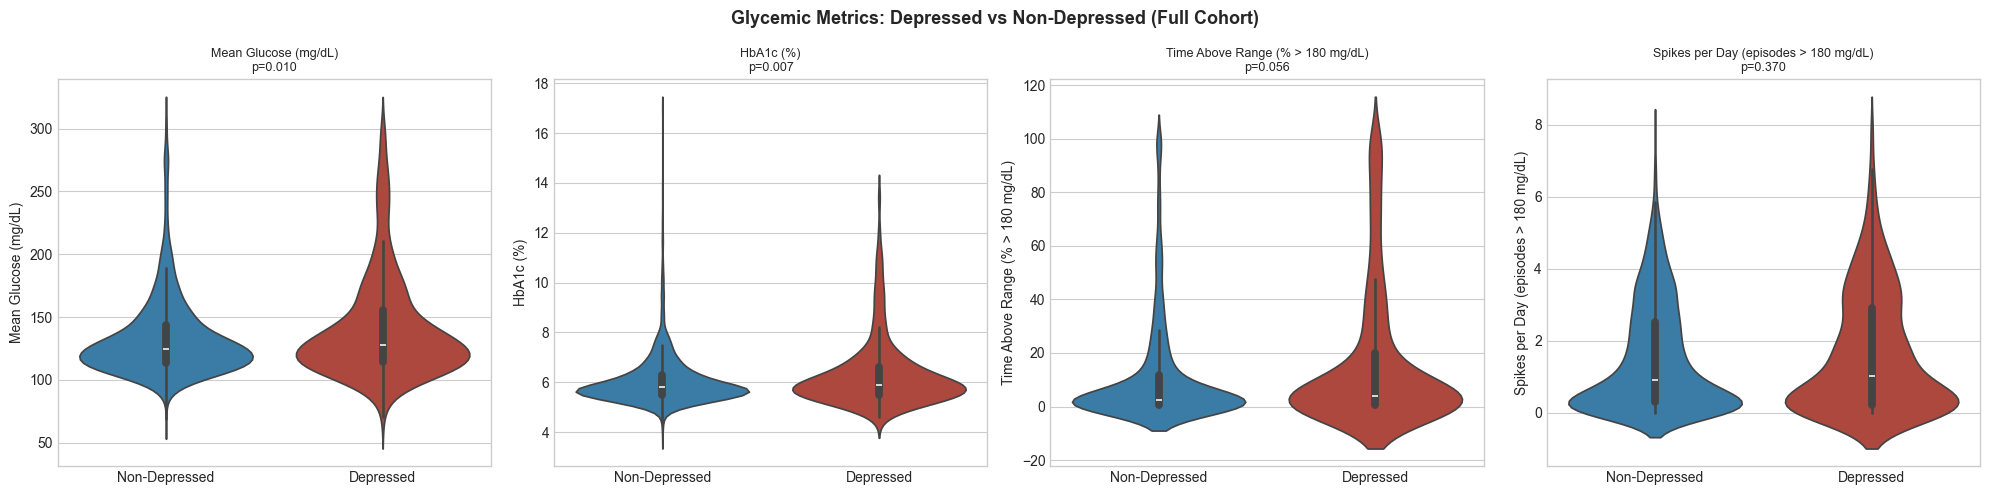

In [8]:
# ── Analysis 1: Overall Depressed vs Non-Depressed ─────────────────

print('=== Overall: Depressed vs Non-Depressed — Glycemic Metrics ===')

overall_results = []
for metric, label in AVAILABLE_METRICS.items():
    dep   = df[df['depressed'] == 1][metric].dropna()
    nodep = df[df['depressed'] == 0][metric].dropna()
    if len(dep) < 5 or len(nodep) < 5:
        continue
    stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
    overall_results.append({
        'metric':  metric,
        'label':   label,
        'n_dep':   len(dep),
        'n_nodep': len(nodep),
        'mean_dep':   round(dep.mean(), 2),
        'mean_nodep': round(nodep.mean(), 2),
        'median_dep':   round(dep.median(), 2),
        'median_nodep': round(nodep.median(), 2),
        'delta_median': round(dep.median() - nodep.median(), 2),
        'p': round(pval, 5),
    })

ov_df = pd.DataFrame(overall_results)
if len(ov_df) > 0:
    _, ov_df['p_fdr'], _, _ = multipletests(ov_df['p'], method='fdr_bh')
    ov_df['significant'] = ov_df['p_fdr'] < 0.05
    print(ov_df[['label', 'n_dep', 'mean_dep', 'mean_nodep',
                  'delta_median', 'p', 'p_fdr', 'significant']].to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────
n_metrics = len(AVAILABLE_METRICS)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
if n_metrics == 1:
    axes = [axes]
fig.suptitle('Glycemic Metrics: Depressed vs Non-Depressed (Full Cohort)',
             fontsize=13, fontweight='bold')

for ax, (metric, label) in zip(axes, AVAILABLE_METRICS.items()):
    sub = df.dropna(subset=[metric, 'dep_label']).copy()
    sns.violinplot(data=sub, x='dep_label', y=metric,
                   order=['Non-Depressed', 'Depressed'],
                   palette=['#2980B9', '#C0392B'], inner='box', ax=ax)
    row = ov_df[ov_df['metric'] == metric]
    title_sfx = f'p={row["p_fdr"].values[0]:.3f}' if len(row) > 0 else ''
    ax.set_title(f'{label}\n{title_sfx}', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

---
## 9. Analysis 2 — By Diabetes Group

> **Question**: Within each diabetes group, are glycemic outcomes significantly worse
> for depressed patients? Does the depression-management gap look different in Healthy
> vs Insulin patients?
>
> **Method**: Mann-Whitney U within each study group per metric. FDR correction
> across all tests.

=== By Diabetes Group: Depressed vs Non-Depressed ===

── Healthy ──
                                label  n_dep  n_nodep  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Mean Glucose (mg/dL)    115      646   117.850     118.020      -0.170  0.684        False
                            HbA1c (%)    114      646     5.550       5.530       0.010  0.932        False
     Time Above Range (% > 180 mg/dL)    114      645     3.030       2.510       0.520  0.306        False
Spikes per Day (episodes > 180 mg/dL)    114      645     0.680       0.750      -0.070  0.306        False

── Pre-DM ──
                                label  n_dep  n_nodep  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Mean Glucose (mg/dL)    115      437   128.210     125.240       2.970  0.759        False
                            HbA1c (%)    113      433     5.870       5.840       0.030  0.684        False
     Time Above Range (% > 180 mg/dL)    115      437

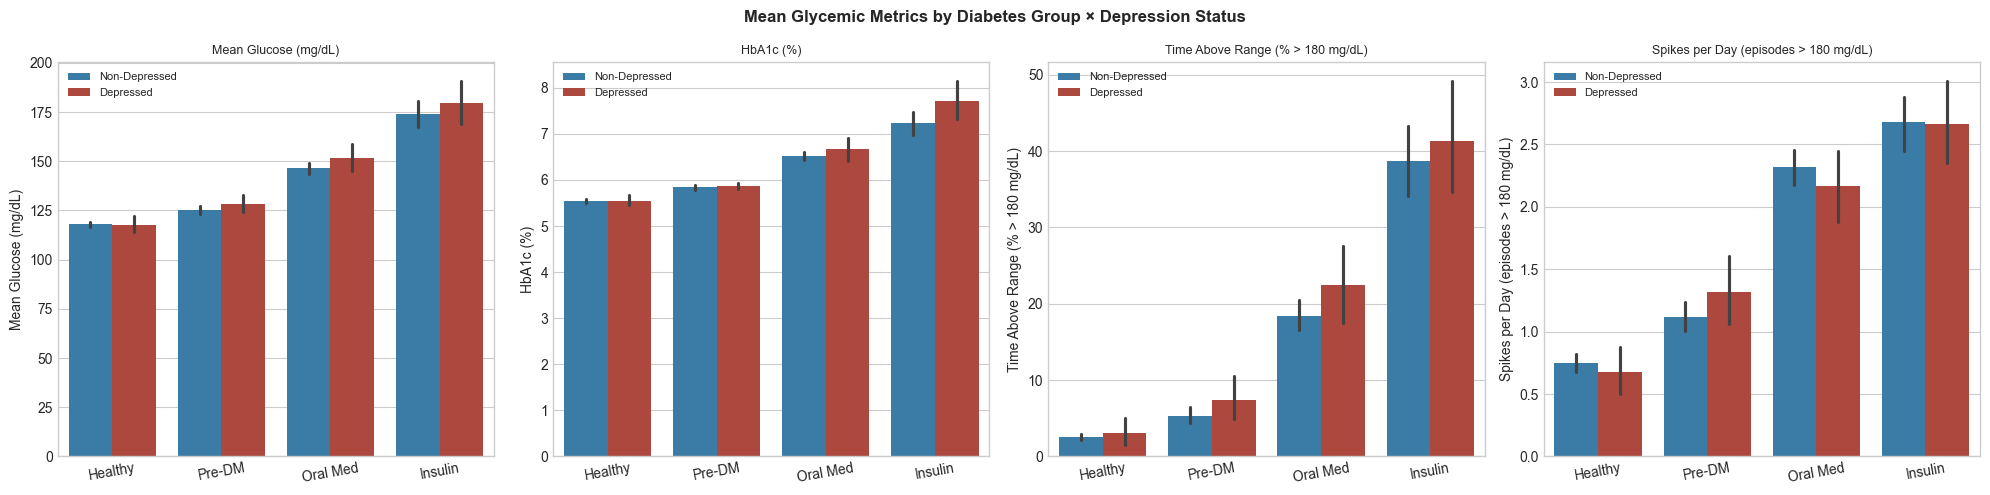

In [9]:
# ── Analysis 2: By Diabetes Group ─────────────────────────────────

group_records = []
for grp in STUDY_GROUP_ORDER:
    sub_grp = df[df['study_group_label'] == grp]
    for metric, label in AVAILABLE_METRICS.items():
        dep   = sub_grp[sub_grp['depressed'] == 1][metric].dropna()
        nodep = sub_grp[sub_grp['depressed'] == 0][metric].dropna()
        if len(dep) < 5 or len(nodep) < 5:
            continue
        stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
        group_records.append({
            'group': grp, 'metric': metric, 'label': label,
            'n_dep': len(dep), 'n_nodep': len(nodep),
            'mean_dep':    round(dep.mean(), 2),
            'mean_nodep':  round(nodep.mean(), 2),
            'delta_mean':  round(dep.mean() - nodep.mean(), 2),
            'p': round(pval, 5),
        })

grp_df = pd.DataFrame(group_records)
if len(grp_df) > 0:
    _, grp_df['p_fdr'], _, _ = multipletests(grp_df['p'], method='fdr_bh')
    grp_df['significant'] = grp_df['p_fdr'] < 0.05

    print('=== By Diabetes Group: Depressed vs Non-Depressed ===')
    for grp in STUDY_GROUP_ORDER:
        sub = grp_df[grp_df['group'] == grp]
        if len(sub) == 0:
            continue
        print(f'\n── {grp} ──')
        print(sub[['label', 'n_dep', 'n_nodep', 'mean_dep', 'mean_nodep',
                    'delta_mean', 'p_fdr', 'significant']].to_string(index=False))

# ── Visualisation: mean metric by group × depression ──────────────
n_metrics = len(AVAILABLE_METRICS)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
if n_metrics == 1:
    axes = [axes]
fig.suptitle('Mean Glycemic Metrics by Diabetes Group × Depression Status',
             fontsize=12, fontweight='bold')

for ax, (metric, label) in zip(axes, AVAILABLE_METRICS.items()):
    sub = df.dropna(subset=[metric, 'dep_label', 'study_group_label']).copy()
    sns.barplot(data=sub, x='study_group_label', y=metric, hue='dep_label',
                order=STUDY_GROUP_ORDER, hue_order=['Non-Depressed', 'Depressed'],
                palette=['#2980B9', '#C0392B'], ax=ax, errorbar='ci')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.legend(title='', fontsize=8)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

---
### Bootstrap robustness check — accounting for class imbalance

> The depressed subgroup is much smaller than the non-depressed one, and smallest of all in
> the **Insulin** group — so a single p-value can hide how *uncertain* each group's estimate is.
> Here we resample each subgroup **with replacement** (5,000×) to get a 95% confidence interval
> for the depressed − non-depressed difference. **Wide CIs (especially Insulin) flag
> low-confidence results driven by small n; CIs that exclude 0 are robust.** The Mann-Whitney /
> FDR tests above are kept — this adds an honest effect-size interval. (Bootstrap, not SMOTE:
> we resample the *real* patients rather than fabricating synthetic ones, which would distort
> these estimates.)

In [10]:
# ── Bootstrap 95% CI for depressed − non-depressed difference (handles imbalance) ──
def bootstrap_diff_ci(a, b, n_boot=5000, seed=0, stat=np.mean):
    """95% percentile CI + two-sided bootstrap p for stat(a) - stat(b), resampling reals only."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    rng = np.random.default_rng(seed)
    boots = np.array([stat(rng.choice(a, a.size, True)) - stat(rng.choice(b, b.size, True))
                      for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    p_boot = 2 * min((boots <= 0).mean(), (boots >= 0).mean())
    return stat(a) - stat(b), lo, hi, p_boot

boot_records = []
for grp in STUDY_GROUP_ORDER:
    sub_grp = df[df['study_group_label'] == grp]
    for metric, label in AVAILABLE_METRICS.items():
        dep   = sub_grp[sub_grp['depressed'] == 1][metric].dropna().values
        nodep = sub_grp[sub_grp['depressed'] == 0][metric].dropna().values
        if len(dep) < 5 or len(nodep) < 5:
            continue
        d, lo, hi, pb = bootstrap_diff_ci(dep, nodep)
        boot_records.append({'group': grp, 'metric': label,
                             'n_dep': len(dep), 'n_nodep': len(nodep),
                             'delta': round(d, 2),
                             'ci_low': round(lo, 2), 'ci_high': round(hi, 2),
                             'CI_excludes_0': not (lo <= 0 <= hi),
                             'boot_p': round(pb, 4)})
boot_df = pd.DataFrame(boot_records)
print('=== Bootstrap 95% CI: depressed − non-depressed difference (by group × metric) ===')
print('(CI excludes 0 = robust; wide CI = low confidence from small/imbalanced n)\n')
for grp in STUDY_GROUP_ORDER:
    sub = boot_df[boot_df['group'] == grp]
    if len(sub) == 0:
        continue
    print(f'── {grp} ──')
    print(sub[['metric', 'n_dep', 'n_nodep', 'delta', 'ci_low', 'ci_high',
               'CI_excludes_0', 'boot_p']].to_string(index=False))
    print()

# Make the imbalance visible: average CI width per group (wider = more undercoverage uncertainty)
boot_df['ci_width'] = boot_df['ci_high'] - boot_df['ci_low']
print('Mean bootstrap CI width by group (wider = more uncertainty from undercoverage):')
print(boot_df.groupby('group', observed=True)['ci_width'].mean()
      .reindex(STUDY_GROUP_ORDER).round(2).to_string())
n_robust = int(boot_df['CI_excludes_0'].sum())
print(f'\n{n_robust} of {len(boot_df)} group × metric comparisons have a 95% CI excluding 0 (robust to imbalance).')

=== Bootstrap 95% CI: depressed − non-depressed difference (by group × metric) ===
(CI excludes 0 = robust; wide CI = low confidence from small/imbalanced n)

── Healthy ──
                               metric  n_dep  n_nodep  delta  ci_low  ci_high  CI_excludes_0  boot_p
                 Mean Glucose (mg/dL)    115      646 -0.170  -4.060    4.500          False   0.886
                            HbA1c (%)    114      646  0.010  -0.090    0.130          False   0.909
     Time Above Range (% > 180 mg/dL)    114      645  0.520  -1.020    2.660          False   0.670
Spikes per Day (episodes > 180 mg/dL)    114      645 -0.070  -0.260    0.140          False   0.468

── Pre-DM ──
                               metric  n_dep  n_nodep  delta  ci_low  ci_high  CI_excludes_0  boot_p
                 Mean Glucose (mg/dL)    115      437  2.970  -1.880    8.210          False   0.230
                            HbA1c (%)    113      433  0.030  -0.060    0.120          False   0.553
     

---
## 10. Analysis 3 — By Age Band

> **Question**: Within each age band, do depressed patients have worse glycemic control?
> Since younger patients have higher depression rates (NB29), and younger diabetic patients
> may also manage glucose differently, the age-stratified comparison is important.
>
> **Method**: Mann-Whitney U within each age band per metric. FDR-corrected.

=== By Age Band: Depressed vs Non-Depressed ===

── <50  (depressed n=124, non-dep n=296) ──
                                label  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Mean Glucose (mg/dL)   140.450     129.730      10.720  0.065        False
                            HbA1c (%)     6.220       5.900       0.320  0.294        False
     Time Above Range (% > 180 mg/dL)    15.710       9.570       6.140  0.294        False
Spikes per Day (episodes > 180 mg/dL)     1.330       1.080       0.250  0.294        False

── 50–59  (depressed n=143, non-dep n=420) ──
                                label  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Mean Glucose (mg/dL)   139.680     132.150       7.520  0.327        False
                            HbA1c (%)     6.380       6.020       0.360  0.065        False
     Time Above Range (% > 180 mg/dL)    16.770      10.050       6.710  0.328        False
Spikes per Day (episodes > 180 m

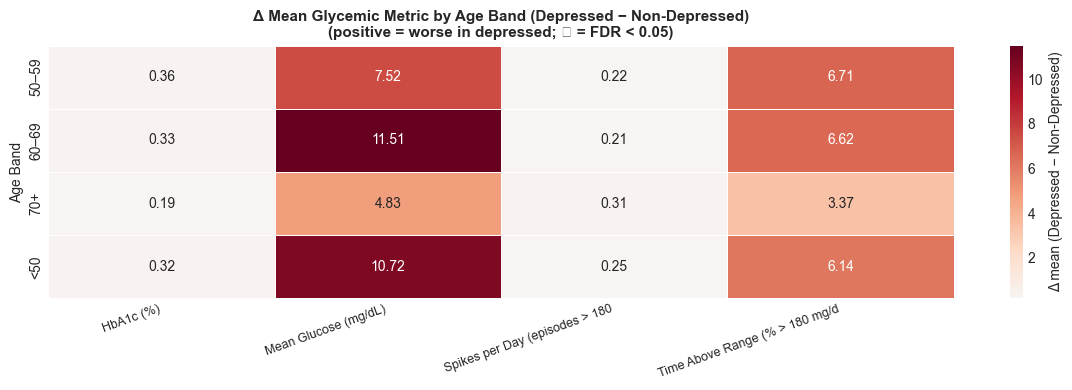

In [11]:
# ── Analysis 3: By Age Band ────────────────────────────────────────

age_records = []
for band in AGE_BAND_LABELS:
    sub_band = df[df['age_band'] == band]
    for metric, label in AVAILABLE_METRICS.items():
        dep   = sub_band[sub_band['depressed'] == 1][metric].dropna()
        nodep = sub_band[sub_band['depressed'] == 0][metric].dropna()
        if len(dep) < 5 or len(nodep) < 5:
            continue
        stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
        age_records.append({
            'age_band': band, 'metric': metric, 'label': label,
            'n_dep': len(dep), 'n_nodep': len(nodep),
            'mean_dep':   round(dep.mean(), 2),
            'mean_nodep': round(nodep.mean(), 2),
            'delta_mean': round(dep.mean() - nodep.mean(), 2),
            'p': round(pval, 5),
        })

age_df = pd.DataFrame(age_records)
if len(age_df) > 0:
    _, age_df['p_fdr'], _, _ = multipletests(age_df['p'], method='fdr_bh')
    age_df['significant'] = age_df['p_fdr'] < 0.05

    print('=== By Age Band: Depressed vs Non-Depressed ===')
    for band in AGE_BAND_LABELS:
        sub = age_df[age_df['age_band'] == band]
        if len(sub) == 0:
            continue
        dep_n   = df[(df['age_band'] == band) & (df['depressed'] == 1)]['depressed'].count()
        nodep_n = df[(df['age_band'] == band) & (df['depressed'] == 0)]['depressed'].count()
        print(f'\n── {band}  (depressed n={dep_n}, non-dep n={nodep_n}) ──')
        print(sub[['label', 'mean_dep', 'mean_nodep',
                    'delta_mean', 'p_fdr', 'significant']].to_string(index=False))

# ── Visualisation: heatmap of delta (dep mean - nodep mean) ────────
if len(age_df) > 0:
    hm_delta = age_df.pivot_table(
        index='age_band', columns='metric', values='delta_mean')
    hm_sig   = age_df.pivot_table(
        index='age_band', columns='metric', values='significant')

    fig, ax = plt.subplots(figsize=(max(6, 3 * len(AVAILABLE_METRICS)), 4))
    sns.heatmap(hm_delta, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Δ mean (Depressed − Non-Depressed)'})
    # Mark significant cells with *
    for i, band in enumerate(AGE_BAND_LABELS):
        for j, metric in enumerate(AVAILABLE_METRICS.keys()):
            if metric in hm_sig.columns and band in hm_sig.index:
                if hm_sig.loc[band, metric]:
                    ax.text(j + 0.85, i + 0.25, '✱', fontsize=12, color='black')
    ax.set_title('Δ Mean Glycemic Metric by Age Band (Depressed − Non-Depressed)\n'
                 '(positive = worse in depressed; ✱ = FDR < 0.05)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Age Band')
    ax.set_xticklabels([GLYCEMIC_METRICS.get(c, c)[:30] for c in hm_delta.columns],
                        rotation=20, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 11. Analysis 4 — Full Stratification: Age Band × Diabetes Group

> **Question**: The core ask — within each combination of age band and diabetes category,
> is there a significant difference in glycemic management between depressed and
> non-depressed subjects?
>
> **Method**: Mann-Whitney U in each (age band × group) cell per metric. Report
> which cells are significant. Note: some cells will have n < 10 and be underpowered.

=== Full Stratification Summary (significant cells only) ===
No cells reach FDR < 0.05 after stratification.

=== Cell-level summary (all cells, primary metric) ===

Δ Mean Mean Glucose (mg/dL) (Depressed − Non-Depressed):
age_band  50–59  60–69    70+    <50
group                               
Healthy  -3.500  5.750 -1.960  0.400
Insulin   5.800  6.510 -4.820  8.690
Oral Med  2.850  7.620 -5.270 20.030
Pre-DM   -0.680  6.810  6.710  2.350


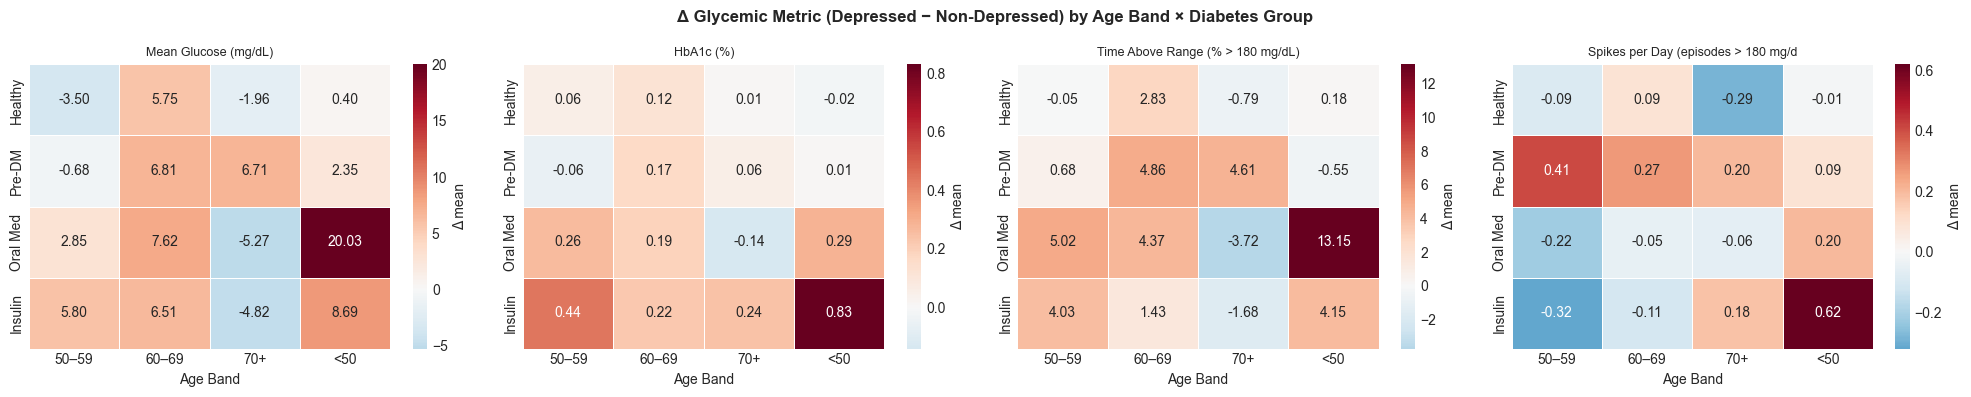

In [12]:
# ── Analysis 4: Full Age × Group Stratification ────────────────────

strat_records = []
for band in AGE_BAND_LABELS:
    for grp in STUDY_GROUP_ORDER:
        cell = df[(df['age_band'] == band) & (df['study_group_label'] == grp)]
        for metric, label in AVAILABLE_METRICS.items():
            dep   = cell[cell['depressed'] == 1][metric].dropna()
            nodep = cell[cell['depressed'] == 0][metric].dropna()
            n_dep, n_nodep = len(dep), len(nodep)
            if n_dep < 5 or n_nodep < 5:
                strat_records.append({
                    'age_band': band, 'group': grp, 'metric': metric, 'label': label,
                    'n_dep': n_dep, 'n_nodep': n_nodep,
                    'mean_dep': np.nan, 'mean_nodep': np.nan,
                    'delta_mean': np.nan, 'p': np.nan,
                    'note': 'n<5'
                })
                continue
            stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
            strat_records.append({
                'age_band': band, 'group': grp, 'metric': metric, 'label': label,
                'n_dep': n_dep, 'n_nodep': n_nodep,
                'mean_dep':   round(dep.mean(), 2),
                'mean_nodep': round(nodep.mean(), 2),
                'delta_mean': round(dep.mean() - nodep.mean(), 2),
                'p': round(pval, 5),
                'note': ''
            })

strat_df = pd.DataFrame(strat_records)
# FDR correct only testable rows
testable = strat_df['p'].notna()
if testable.sum() > 0:
    _, strat_df.loc[testable, 'p_fdr'], _, _ = multipletests(
        strat_df.loc[testable, 'p'], method='fdr_bh')
strat_df['p_fdr']       = strat_df.get('p_fdr', np.nan)
strat_df['significant'] = strat_df['p_fdr'] < 0.05

print('=== Full Stratification Summary (significant cells only) ===')
sig_cells = strat_df[strat_df['significant'] == True].sort_values(
    ['metric', 'age_band', 'group'])
if len(sig_cells) > 0:
    print(sig_cells[['age_band', 'group', 'label', 'n_dep', 'n_nodep',
                      'mean_dep', 'mean_nodep', 'delta_mean', 'p_fdr']].to_string(index=False))
else:
    print('No cells reach FDR < 0.05 after stratification.')

print('\n=== Cell-level summary (all cells, primary metric) ===')
primary = list(AVAILABLE_METRICS.keys())[0]  # mean_glucose first if available
prim_strat = strat_df[strat_df['metric'] == primary].copy()
prim_pivot = prim_strat.pivot_table(
    index='group', columns='age_band',
    values='delta_mean', aggfunc='first')
print(f'\nΔ Mean {GLYCEMIC_METRICS[primary]} (Depressed − Non-Depressed):')
print(prim_pivot.to_string())

# Visualisation: one heatmap per metric of delta_mean
n_metrics = len(AVAILABLE_METRICS)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4))
if n_metrics == 1:
    axes = [axes]
fig.suptitle('Δ Glycemic Metric (Depressed − Non-Depressed) by Age Band × Diabetes Group',
             fontsize=12, fontweight='bold')

for ax, (metric, label) in zip(axes, AVAILABLE_METRICS.items()):
    sub = strat_df[strat_df['metric'] == metric]
    piv = sub.pivot_table(index='group', columns='age_band',
                           values='delta_mean', aggfunc='first')
    piv = piv.reindex(index=STUDY_GROUP_ORDER)
    sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Δ mean'})
    # Mark significant cells
    sig_sub = sub[sub['significant'] == True]
    for _, row in sig_sub.iterrows():
        if row['age_band'] in piv.columns and row['group'] in piv.index:
            j = list(piv.columns).index(row['age_band'])
            i = list(piv.index).index(row['group'])
            ax.text(j + 0.85, i + 0.25, '✱', fontsize=12, color='black')
    ax.set_title(label[:35], fontsize=9)
    ax.set_xlabel('Age Band')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

---
## 12. Analysis 5 — Regression: Does Depression Independently Predict Glycemic Outcomes?

> **Question**: After controlling for age and diabetes group, is depression status still
> a significant predictor of glycemic outcomes? This separates the depression effect
> from the confounds of being older or in a more severe diabetes group.
>
> **Method**: OLS for each metric: `metric ~ depressed + study_group_code + age_std`.
> Also test whether the depression × group interaction is significant.

=== OLS Regression: metric ~ depressed + group_code + age_std ===

── Mean Glucose (mg/dL) (n=2,244) ──
  Model A R²=0.2736
  depressed coef=3.816  p=0.0175  *
  group_code coef=17.415  p=0.0000
  age_std coef=0.933  p=0.1416
  Interaction (dep × group) p=0.0163  *

── HbA1c (%) (n=2,210) ──
  Model A R²=0.2914
  depressed coef=0.150  p=0.0034  **
  group_code coef=0.569  p=0.0000
  age_std coef=0.035  p=0.0832
  Interaction (dep × group) p=0.0003  ***

── Time Above Range (% > 180 mg/dL) (n=2,242) ──
  Model A R²=0.2684
  depressed coef=2.764  p=0.0059  **
  group_code coef=10.708  p=0.0000
  age_std coef=0.474  p=0.2315
  Interaction (dep × group) p=0.0141  *

── Spikes per Day (episodes > 180 mg/dL) (n=2,242) ──
  Model A R²=0.2397
  depressed coef=0.030  p=0.6787  ns
  group_code coef=0.704  p=0.0000
  age_std coef=0.167  p=0.0000
  Interaction (dep × group) p=0.6091  ns

=== Regression Summary Table ===
                                label    n    r2  dep_coef  dep_p  dep_sig  in

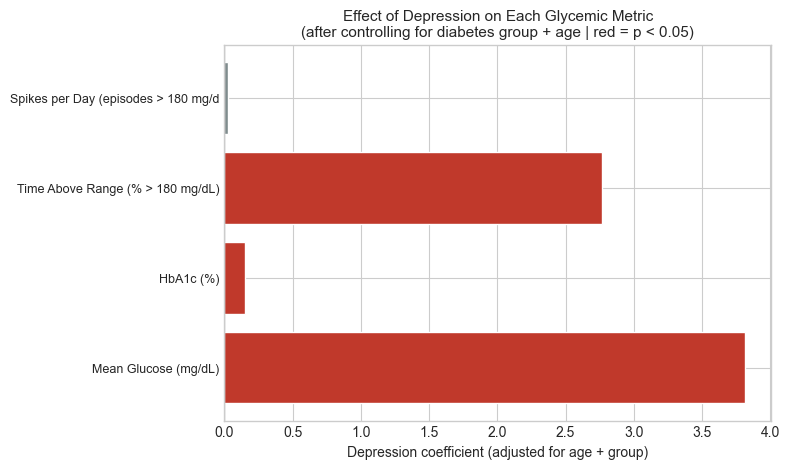

In [13]:
# ── Analysis 5: Regression ─────────────────────────────────────────

print('=== OLS Regression: metric ~ depressed + group_code + age_std ===')
reg_results = []

for metric, label in AVAILABLE_METRICS.items():
    sub = df.dropna(subset=[metric, 'depressed', 'study_group_code', 'age_std']).copy()
    if len(sub) < 50:
        continue

    # Model A: additive
    mod_a = smf.ols(f'{metric} ~ depressed + study_group_code + age_std', data=sub).fit()
    # Model B: with depression × group interaction
    mod_b = smf.ols(f'{metric} ~ depressed * study_group_code + age_std', data=sub).fit()

    dep_coef = mod_a.params.get('depressed', np.nan)
    dep_p    = mod_a.pvalues.get('depressed', np.nan)
    grp_coef = mod_a.params.get('study_group_code', np.nan)
    age_coef = mod_a.params.get('age_std', np.nan)
    int_p    = mod_b.pvalues.get('depressed:study_group_code', np.nan)

    print(f'\n── {label} (n={len(sub):,}) ──')
    print(f'  Model A R²={mod_a.rsquared:.4f}')
    print(f'  depressed coef={dep_coef:.3f}  p={dep_p:.4f}'
          + ('  ***' if dep_p < 0.001 else '  **' if dep_p < 0.01
             else '  *' if dep_p < 0.05 else '  ns'))
    print(f'  group_code coef={grp_coef:.3f}  p={mod_a.pvalues.get("study_group_code", np.nan):.4f}')
    print(f'  age_std coef={age_coef:.3f}  p={mod_a.pvalues.get("age_std", np.nan):.4f}')
    print(f'  Interaction (dep × group) p={int_p:.4f}'
          + ('  ***' if int_p < 0.001 else '  **' if int_p < 0.01
             else '  *' if int_p < 0.05 else '  ns'))

    reg_results.append({
        'metric': metric, 'label': label, 'n': len(sub),
        'r2': round(mod_a.rsquared, 4),
        'dep_coef': round(dep_coef, 3),
        'dep_p': round(dep_p, 4),
        'dep_sig': dep_p < 0.05,
        'interaction_p': round(int_p, 4) if not np.isnan(int_p) else np.nan,
        'interaction_sig': int_p < 0.05 if not np.isnan(int_p) else False,
    })

print('\n=== Regression Summary Table ===')
reg_df = pd.DataFrame(reg_results)
if len(reg_df) > 0:
    print(reg_df[['label', 'n', 'r2', 'dep_coef', 'dep_p', 'dep_sig',
                   'interaction_p', 'interaction_sig']].to_string(index=False))

# ── Visualisation: coefficient forest plot ─────────────────────────
if len(reg_df) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(reg_df) * 1.2)))
    colors_bar = ['#C0392B' if s else '#7F8C8D' for s in reg_df['dep_sig']]
    ax.barh(reg_df['label'].apply(lambda x: x[:35]),
            reg_df['dep_coef'], color=colors_bar, edgecolor='white')
    ax.axvline(0, color='#333', linewidth=0.8)
    ax.set_xlabel('Depression coefficient (adjusted for age + group)', fontsize=10)
    ax.set_title('Effect of Depression on Each Glycemic Metric\n'
                 '(after controlling for diabetes group + age | red = p < 0.05)', fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

---
## Key Findings

> Full interpretation lives in this notebook's report.

**Depression independently predicts worse chronic glycemic control, and the gap grows with diabetes severity — but it is modest and, within the small Insulin subgroup, uncertain.**

1. **Overall (Analysis 1):** depressed patients have significantly higher mean glucose (+3.3 mg/dL, FDR=0.010) and HbA1c (+0.10%, FDR=0.007). Time-above-range is borderline (FDR=0.056); spike frequency is not different — depression affects *chronic* control, not acute excursions.

2. **By diabetes group (Analysis 2):** the gap scales with severity (Healthy ≈ 0 → Insulin +5.7 mg/dL, +0.49% HbA1c) but no single group survives FDR — the depressed subgroups are small (depressed Insulin n=79).

3. **By age (Analysis 3):** all age bands show positive gaps; none survives FDR individually. Smallest gap at 70+, consistent with NB29.

4. **Regression (Analysis 5):** after adjusting for diabetes group and age, depression independently predicts mean glucose (+3.8 mg/dL, p=0.018), HbA1c (+0.15%, p=0.003), and TAR (+2.8%, p=0.006) — not spikes. The group × depression interaction is significant for HbA1c (p<0.001): the gap is ~0 in Healthy and largest in Insulin.

5. **Bootstrap robustness (Analysis 2b):** resampling each subgroup confirms the imbalance problem — CI widths grow Healthy → Insulin, and only **1 of 16** group × metric differences has a 95% CI excluding 0: the **Insulin HbA1c gap (+0.49% [0.03, 0.98])**. So the headline Insulin effect is directionally real but rests on few patients.

**Key takeaway:** depression adds a small, independent chronic-glycemic burden that concentrates in insulin-dependent patients — clinically meaningful but statistically fragile at this sample size.